# Awning AI — Multi-Agent Pipeline Sandbox

Develop and test a 3-layer agent architecture:

- **Workers** — four specialist analysts (wind, rain, forecast, solar) that each return a JSON risk/benefit assessment
- **Coordinator** — receives all worker assessments and produces a concise operational brief
- **Orchestrator** — reads the brief, makes the final deploy/retract/none decision, calls awning tools, and schedules the next evaluation

### Workflow
1. **Section 1** — set model, `AIConfig`, and scoring weights
2. **Sections 2–4** — edit prompts for workers, coordinator, and orchestrator
3. **Section 5** — run once to load all implementation helpers
4. **Section 6** — fast single-scenario iteration
5. **Section 7** — inspect each pipeline layer for the last single run
6. **Section 8** — batch all 30 scenarios
7. **Sections 9–11** — results table, visualization, drill-down

In [46]:
from pydantic import Field, BaseModel

In [48]:
class _AIConfig(BaseModel):
    aienabled: bool = Field(description="AI features are enabled", default=True) 

In [49]:
_test = _AIConfig()

In [52]:
_test

_AIConfig(aienabled=True)

## Section 0 — Setup

In [1]:
import sys
import os
import json
import re
from pathlib import Path
from dataclasses import dataclass, field
from typing import Any, Dict, List, Optional, Tuple

PROJECT_ROOT = Path('.').resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from dotenv import load_dotenv
load_dotenv(PROJECT_ROOT / '.env')

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from app.ai_agent import _Claude
from app.ai_tools import action_tool_schemas
from app.config import AIConfig
from scenarios import SCENARIOS, SCENARIOS_BY_NAME

_MPH_PER_MS = 2.23694
_C_TO_F = lambda c: round(c * 9 / 5 + 32, 1)

api_key_set = bool(os.environ.get('ANTHROPIC_API_KEY', '').strip())
print(f'Project root : {PROJECT_ROOT}')
print(f'Scenarios    : {len(SCENARIOS)}')
print(f'API key set  : {api_key_set}')

Project root : /Users/mcdomx/Library/Mobile Documents/com~apple~CloudDocs/myProjects/home_automation/awning_protector
Scenarios    : 30
API key set  : True


/Users/mcdomx/.local/share/virtualenvs/awning_protector-3b7VvvC5/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Section 1 — Configuration

Edit this cell to change model, thresholds, or scoring weights.

In [2]:
CLAUDE_MODEL = os.environ.get('CLAUDE_MODEL', 'claude-haiku-4-5')

AI_CFG = AIConfig(
    ai_enabled=True,
    current_wind_threshold_mph=3.0,
    forecasted_wind_threshold_mph=8.0,
    earliest_auto_deployment='8AM',
    latest_auto_deployment='7PM',
    forecast_outlook_hours=2,
    max_deployment_seconds=15,
    min_deployment_seconds=2,
    min_deployment_temp_f=65.0,
    min_eval_interval_seconds=300,
)

WEIGHTS = {
    'protection':       0.5,
    'solar_shielding':  0.3,
    'token_efficiency': 0.2,
}

FORECAST_RAIN_PROB_THRESHOLD = 0.30  # flag forecast rain >= this probability
MAX_TOKENS_REFERENCE = 10000         # normalization ceiling for token scoring

print(f'Model         : {CLAUDE_MODEL}')
print(f'Wind limit    : {AI_CFG.current_wind_threshold_mph} mph now / {AI_CFG.forecasted_wind_threshold_mph} mph forecast')
print(f'Rain limit    : pop >= {FORECAST_RAIN_PROB_THRESHOLD:.0%} within {AI_CFG.forecast_outlook_hours}h')
print(f'Deploy window : {AI_CFG.earliest_auto_deployment} – {AI_CFG.latest_auto_deployment}')
print(f'Temp limit    : > {AI_CFG.min_deployment_temp_f}°F')
print(f'Duration      : {AI_CFG.min_deployment_seconds}–{AI_CFG.max_deployment_seconds}s')

Model         : claude-haiku-4-5
Wind limit    : 3.0 mph now / 8.0 mph forecast
Rain limit    : pop >= 30% within 2h
Deploy window : 8AM – 7PM
Temp limit    : > 65.0°F
Duration      : 2–15s


## Section 2 — Worker Prompts

Each worker receives pre-formatted text (no tool calls) and returns a JSON object.
Edit and re-run this cell to iterate on worker instructions.

In [4]:
WIND_WORKER_PROMPT = f'''You are a wind safety analyst for a retractable outdoor awning.

Analyze the wind data provided. Wind above {AI_CFG.current_wind_threshold_mph} mph is dangerous.
A steady rising trend approaching this threshold also warrants a warning.

Return ONLY valid JSON — no markdown fences, no extra text:
{{
  "risk": "none|low|moderate|high",
  "current_mph": <number>,
  "trend": "stable|rising|falling",
  "reasoning": "<one sentence>"
}}'''

RAIN_WORKER_PROMPT = '''You are a precipitation safety analyst for a retractable outdoor awning.

Analyze the precipitation data provided.
Any active rain (precip_type != 0 or rain_prev_min_mm > 0) is an immediate hazard.
Rain seen in recent history should also be noted even if currently clear.

Return ONLY valid JSON — no markdown fences, no extra text:
{
  "risk": "none|low|moderate|high",
  "active_rain": <true|false>,
  "recent_rain_in_history": <true|false>,
  "reasoning": "<one sentence>"
}'''

FORECAST_WORKER_PROMPT = f'''You are a weather forecast analyst for a retractable outdoor awning.

Analyze the forecast. Consider only the next {AI_CFG.forecast_outlook_hours} hours.
Risk thresholds within that window:
  rain probability >= {FORECAST_RAIN_PROB_THRESHOLD:.0%}  OR  wind >= {AI_CFG.forecasted_wind_threshold_mph} mph

Return ONLY valid JSON — no markdown fences, no extra text:
{{
  "risk": "none|low|moderate|high",
  "hours_until_risk": <integer or null if no risk in window>,
  "rain_prob_max": <float 0.0–1.0, highest in window>,
  "wind_mph_max": <float, highest in window>,
  "reasoning": "<one sentence>"
}}'''

SOLAR_WORKER_PROMPT = f'''You are a solar shielding benefit analyst for a home awning.

Evaluate whether current solar and temperature conditions justify deploying the awning.
Criteria (ALL must hold for any benefit):
  - Temperature > {AI_CFG.min_deployment_temp_f}°F
  - Illuminance > 10000 lux
  - Current time between {AI_CFG.earliest_auto_deployment} and {AI_CFG.latest_auto_deployment}
UV index >= 6 increases the benefit level.

Return ONLY valid JSON — no markdown fences, no extra text:
{{
  "deploy_benefit": "none|low|moderate|high",
  "temp_f": <number>,
  "lux": <integer>,
  "uv_index": <number>,
  "within_time_window": <true|false>,
  "reasoning": "<one sentence>"
}}'''

print('Worker prompts defined.')

Worker prompts defined.


## Section 3 — Coordinator Prompt

The coordinator receives all four worker JSON assessments and the current awning state.
It produces a concise brief (plain text) for the orchestrator.

In [5]:
COORDINATOR_PROMPT = '''You are the coordinator for an awning control system.

You receive structured assessments from four specialist workers and produce a concise
operational brief for the orchestrator who will make the final decision.

If any worker agent reports 'moderate' or 'high' risk, stop the workflow and report to the orchestrator the collected results and suggest retracting the awning or avoiding deployment.

Your brief must cover:
1. One-sentence summary for each worker finding (wind, rain, forecast, solar)
2. Overall situation: SAFE_TO_DEPLOY | MUST_RETRACT | NO_ACTION | UNCERTAIN
3. The primary driver (most important factor)
4. Current awning state and current time
5. A recommendation on how far the awning should be deployed in seconds
6. Whether current time is within the allowed deployment window

Be concise — under 150 words. The orchestrator makes the final call.'''

print('Coordinator prompt defined.')

Coordinator prompt defined.


## Section 4 — Orchestrator Prompt

The orchestrator reads the coordinator brief, uses awning tools to act,
then emits a structured report including the next evaluation interval.

In [23]:
ORCHESTRATOR_PROMPT = f'''You are the orchestrator for an automated outdoor awning system.

<primary_objective>Protect the awning from damage. NEVER deploy in hazardous conditions.</primary_objective>
<secondary_objective>Shield the home from solar heat when safe to do so.</secondary_objective>

<hard_rules>
- Never deploy if wind > {AI_CFG.current_wind_threshold_mph} mph or any precipitation is active
- Never deploy if forecast shows rain prob >= 30% or wind >= {AI_CFG.forecasted_wind_threshold_mph} mph within {AI_CFG.forecast_outlook_hours} hours
- Never deploy before {AI_CFG.earliest_auto_deployment} or after {AI_CFG.latest_auto_deployment}
- Only deploy if temperature > {AI_CFG.min_deployment_temp_f}°F
- Deployment duration must be {AI_CFG.min_deployment_seconds}–{AI_CFG.max_deployment_seconds} seconds
</hard_rules>

<soft_rules>
- Favor more seconds of deployment when hot, sunny, high solar intensity and forecast is clearly safe for several hours
- Deploy the awning for smaller seconds if there is uncertaintly in the weather or the solor intensity is lower.
- Avoid oscillating — when conditions hover near thresholds, prefer stability
- Don't deploy if you determine that the conditions require reevaluation within 15 minutes. Never wait more than 75 minutes before reevaluating.
</soft_rules>

You receive a coordinator brief. Steps:
1. If the coordinator reports any 'moderate' or 'high' risk from any workers retract the awning regardless of current state and stop subsequent actions.
2. Call get_awning_status to confirm current state
3. Execute the appropriate action: deploy_awning(seconds), retract_awning(), or nothing
4. Call log_awning_action with the action and reason
5. Determine when to reevaluate the deployment. Avoid spending tokens on reevaluation if the conditions are stable and favorable for deployment.
6. Output a report in this exact format (no other text):

ORCHESTRATOR REPORT
-------------------
Action Taken:     <deployed N seconds | retracted | none>
Next Eval In:     <integer seconds>
Risk Assessment:  <none|low|moderate|high>
Forecast Risk:    <none|low|moderate|high>
Solar Benefit:    <none|low|moderate|high>
Primary Reason:   <one sentence>'''

print('Orchestrator prompt defined.')

Orchestrator prompt defined.


## Section 5 — Pipeline Implementation

Run this cell once to load all dataclasses and functions. No edits needed here.

In [24]:
# ── Dataclasses ──────────────────────────────────────────────────────────────

@dataclass
class WorkerResult:
    name: str
    assessment: Dict[str, Any]
    raw_response: str
    input_tokens: int
    output_tokens: int
    error: Optional[str] = None


@dataclass
class MultiAgentResult:
    scenario_name: str
    action_taken: str           # deploy | retract | none | error
    deploy_seconds: Optional[int]
    next_eval_seconds: Optional[int]

    wind: WorkerResult
    rain: WorkerResult
    forecast: WorkerResult
    solar: WorkerResult
    coordinator_brief: str
    orchestrator_report: str
    orchestrator_tool_calls: List[str]

    worker_tokens: int
    coordinator_tokens: int
    orchestrator_tokens: int
    total_tokens: int
    error: Optional[str] = None


print('Dataclasses ready.')

Dataclasses ready.


In [25]:
# ── Helpers ───────────────────────────────────────────────────────────────────

def _parse_json(raw: str, worker_name: str) -> Tuple[Dict, Optional[str]]:
    text = raw.strip()
    # Strip markdown fences if present
    if text.startswith('```'):
        text = re.sub(r'```[a-z]*\n?', '', text).strip()
    start = text.find('{')
    end   = text.rfind('}') + 1
    if start >= 0 and end > start:
        try:
            return json.loads(text[start:end]), None
        except json.JSONDecodeError as exc:
            return {}, f'JSON parse error in {worker_name}: {exc}'
    return {}, f'No JSON found in {worker_name} response'


def _extract_action(action_log: List[str]) -> Tuple[str, Optional[int]]:
    for entry in reversed(action_log):
        if entry.startswith('deploy:'):
            secs = None
            try:
                secs = int(entry.split(':')[1].replace('s', ''))
            except Exception:
                pass
            return 'deploy', secs
        if entry.startswith('retract:'):
            return 'retract', None
    return 'none', None


def _parse_next_eval(report: str, default: int) -> int:
    m = re.search(r'Next Eval In:\s*(\d+)', report, re.IGNORECASE)
    return int(m.group(1)) if m else default


def _sys(text: str) -> list:
    return [{'type': 'text', 'text': text, 'cache_control': {'type': 'ephemeral'}}]


print('Helpers ready.')

Helpers ready.


In [36]:
# ── Worker functions ──────────────────────────────────────────────────────────

def run_wind_worker(scenario: Dict, claude: _Claude, prompt: str) -> WorkerResult:
    obs = scenario['current_obs']
    wind_mph = round(obs['wind_avg_m_s'] * _MPH_PER_MS, 2)   
    history = scenario.get('history', [])

    lines = [f'Current wind: {wind_mph} mph', '', 'Wind history (oldest first):']
    for e in history:
        ts = e.get('timestamp', '?')
        w = round(e.get('wind_avg_m_s', 0) * _MPH_PER_MS, 2)
        lines.append(f'  {ts}  {w} mph')
    user_msg = '\n'.join(lines)

    msgs = []
    claude.add_user_message(msgs, user_msg)
    resp = claude.chat(msgs, system_blocks=_sys(prompt), temperature=0)
    raw = claude.text_from_message(resp)
    assessment, err = _parse_json(raw, 'wind')
    return WorkerResult('wind', assessment, raw, resp.usage.input_tokens, resp.usage.output_tokens, err)


def run_rain_worker(scenario: Dict, claude: _Claude, prompt: str) -> WorkerResult:
    obs = scenario['current_obs']
    history = scenario.get('history', [])

    lines = [
        f'Current precip_type   : {obs["precip_type"]} (0=none, 1=rain, 2=hail)',
        f'Current rain/prev min : {obs["rain_prev_min_mm"]} mm',
        '',
        'Precipitation history (oldest first):',
    ]
    for e in history:
        ts = e.get('timestamp', '?')
        pt = e.get('precip_type', 0)
        rm = e.get('rain_prev_min_mm', 0.0)
        lines.append(f'  {ts}  precip_type={pt}  rain={rm} mm')
    user_msg = '\n'.join(lines)

    msgs = []
    claude.add_user_message(msgs, user_msg)
    resp = claude.chat(msgs, system_blocks=_sys(prompt), temperature=0)
    raw = claude.text_from_message(resp)
    assessment, err = _parse_json(raw, 'rain')
    return WorkerResult('rain', assessment, raw, resp.usage.input_tokens, resp.usage.output_tokens, err)


def run_forecast_worker(scenario: Dict, claude: _Claude, prompt: str) -> WorkerResult:
    from datetime import datetime, timezone
    forecast = scenario.get('forecast', [])

    lines = [f'Current time: {scenario["current_time"]}', '', 'Forecast (hourly, starting ~1h from now):']
    for e in forecast:
        try:
            ts = datetime.fromtimestamp(e.get('dt', 0), tz=timezone.utc).strftime('%H:%M UTC')
        except Exception:
            ts = '?'
        desc = e.get('description', '?')
        pop  = e.get('pop', 0)
        w    = e.get('wind_mph', 0)
        tc   = e.get('temp_c', '?')
        lines.append(f'  {ts}  {desc}  rain_prob={pop:.0%}  wind={w}mph  temp={tc}C')
    user_msg = '\n'.join(lines)

    msgs = []
    claude.add_user_message(msgs, user_msg)
    resp = claude.chat(msgs, system_blocks=_sys(prompt), temperature=0)
    raw = claude.text_from_message(resp)
    assessment, err = _parse_json(raw, 'forecast')
    return WorkerResult('forecast', assessment, raw, resp.usage.input_tokens, resp.usage.output_tokens, err)


def run_solar_worker(scenario: Dict, claude: _Claude, prompt: str) -> WorkerResult:
    obs = scenario['current_obs']
    temp_f = _C_TO_F(obs['air_temp_c'])
    user_msg = '\n'.join([
        f'Current time  : {scenario["current_time"]}',
        f'Temperature   : {obs["air_temp_c"]}\u00b0C  ({temp_f}\u00b0F)',
        f'Illuminance   : {obs["illuminance_lux"]} lux',
        f'UV index      : {obs["uv_index"]}',
    ])

    msgs = []
    claude.add_user_message(msgs, user_msg)
    resp = claude.chat(msgs, system_blocks=_sys(prompt), temperature=0)
    raw = claude.text_from_message(resp)
    assessment, err = _parse_json(raw, 'solar')
    return WorkerResult('solar', assessment, raw, resp.usage.input_tokens, resp.usage.output_tokens, err)


print('Worker functions ready.')

Worker functions ready.


In [27]:
# ── Coordinator ───────────────────────────────────────────────────────────────

def run_coordinator(
    wind: WorkerResult, rain: WorkerResult,
    forecast: WorkerResult, solar: WorkerResult,
    scenario: Dict, claude: _Claude, prompt: str,
) -> Tuple[str, int, int]:
    user_msg = '\n'.join([
        f'AWNING STATE : {scenario["awning_state"]}',
        f'CURRENT TIME : {scenario["current_time"]}',
        '',
        'WIND WORKER:',
        json.dumps(wind.assessment, indent=2),
        '',
        'RAIN WORKER:',
        json.dumps(rain.assessment, indent=2),
        '',
        'FORECAST WORKER:',
        json.dumps(forecast.assessment, indent=2),
        '',
        'SOLAR WORKER:',
        json.dumps(solar.assessment, indent=2),
    ])
    msgs = []
    claude.add_user_message(msgs, user_msg)
    resp = claude.chat(msgs, system_blocks=_sys(prompt), temperature=0)
    brief = claude.text_from_message(resp)
    return brief, resp.usage.input_tokens, resp.usage.output_tokens


# ── Orchestrator ──────────────────────────────────────────────────────────────

def run_orchestrator(
    brief: str, scenario: Dict, claude: _Claude, prompt: str,
) -> Tuple[str, List[str], List[str], int, int]:
    """Returns (report, action_log, tool_call_names, in_tokens, out_tokens)."""
    action_log: List[str] = []

    def deploy_awning(seconds: int = 3) -> str:
        action_log.append(f'deploy:{seconds}s')
        return f'Awning deployed for {seconds} seconds.'

    def retract_awning(seconds: int = None) -> str:
        label = f'retract:{seconds}s' if seconds is not None else 'retract:full'
        action_log.append(label)
        return f'Awning retracted for {seconds} seconds.' if seconds else 'Awning fully retracted.'

    def log_awning_action(action: str, reason: str) -> str:
        action_log.append(f'log:{action}')
        return f'Logged: {action} ({reason})'

    def get_awning_status() -> str:
        return json.dumps({'state': scenario['awning_state']})

    dispatch = {
        'deploy_awning':    deploy_awning,
        'retract_awning':   retract_awning,
        'log_awning_action': log_awning_action,
        'get_awning_status': get_awning_status,
    }

    msgs = []
    claude.add_user_message(msgs, brief)
    total_in = total_out = 0
    tool_names: List[str] = []
    report = ''

    while True:
        resp = claude.chat(
            msgs,
            system_blocks=_sys(prompt),
            temperature=0,
            tools=action_tool_schemas,
        )
        total_in  += resp.usage.input_tokens
        total_out += resp.usage.output_tokens
        claude.add_assistant_message(msgs, resp)

        if resp.stop_reason == 'end_turn':
            report = claude.text_from_message(resp)
            break

        tool_results = []
        for block in resp.content:
            if block.type == 'tool_use':
                tool_names.append(block.name)
                fn = dispatch.get(block.name)
                result = fn(**block.input) if fn else f'Unknown tool: {block.name}'
                tool_results.append({
                    'type': 'tool_result',
                    'tool_use_id': block.id,
                    'content': result,
                })

        if not tool_results:
            break
        msgs.append({'role': 'user', 'content': tool_results})

    return report, action_log, tool_names, total_in, total_out


print('Coordinator and orchestrator ready.')

Coordinator and orchestrator ready.


In [28]:
# ── Main pipeline ─────────────────────────────────────────────────────────────

def run_pipeline(
    scenario: Dict,
    claude: _Claude,
    wind_prompt: str,
    rain_prompt: str,
    forecast_prompt: str,
    solar_prompt: str,
    coordinator_prompt: str,
    orchestrator_prompt: str,
    cfg: AIConfig,
) -> MultiAgentResult:

    try:
        wind_r     = run_wind_worker(scenario, claude, wind_prompt)
        rain_r     = run_rain_worker(scenario, claude, rain_prompt)
        forecast_r = run_forecast_worker(scenario, claude, forecast_prompt)
        solar_r    = run_solar_worker(scenario, claude, solar_prompt)

        worker_tokens = sum([
            wind_r.input_tokens + wind_r.output_tokens,
            rain_r.input_tokens + rain_r.output_tokens,
            forecast_r.input_tokens + forecast_r.output_tokens,
            solar_r.input_tokens + solar_r.output_tokens,
        ])

        brief, ci, co = run_coordinator(
            wind_r, rain_r, forecast_r, solar_r,
            scenario, claude, coordinator_prompt,
        )
        coord_tokens = ci + co

        report, action_log, tool_names, oi, oo = run_orchestrator(
            brief, scenario, claude, orchestrator_prompt,
        )
        orch_tokens = oi + oo

        action, deploy_secs = _extract_action(action_log)
        next_eval = _parse_next_eval(report, cfg.min_eval_interval_seconds)
        total = worker_tokens + coord_tokens + orch_tokens

        return MultiAgentResult(
            scenario_name=scenario['name'],
            action_taken=action,
            deploy_seconds=deploy_secs,
            next_eval_seconds=next_eval,
            wind=wind_r, rain=rain_r, forecast=forecast_r, solar=solar_r,
            coordinator_brief=brief,
            orchestrator_report=report,
            orchestrator_tool_calls=tool_names,
            worker_tokens=worker_tokens,
            coordinator_tokens=coord_tokens,
            orchestrator_tokens=orch_tokens,
            total_tokens=total,
        )

    except Exception as exc:
        dummy = WorkerResult('?', {}, '', 0, 0, str(exc))
        return MultiAgentResult(
            scenario_name=scenario['name'],
            action_taken='error',
            deploy_seconds=None, next_eval_seconds=None,
            wind=dummy, rain=dummy, forecast=dummy, solar=dummy,
            coordinator_brief='', orchestrator_report='',
            orchestrator_tool_calls=[],
            worker_tokens=0, coordinator_tokens=0,
            orchestrator_tokens=0, total_tokens=0,
            error=str(exc),
        )


# ── Scoring helper ────────────────────────────────────────────────────────────

def score_pipeline_results(results: List[MultiAgentResult]) -> List[Dict]:
    rows = []
    for r in results:
        sc = SCENARIOS_BY_NAME[r.scenario_name]
        expected   = sc['expected_action']
        correct    = r.action_taken == expected
        objectives = sc['objectives']

        p_score = (1.0 if correct else 0.0) if 'protection'      in objectives else None
        s_score = (1.0 if correct else 0.0) if 'solar_shielding' in objectives else None
        t_score = 1.0 - min(r.total_tokens / max(MAX_TOKENS_REFERENCE, 1), 1.0)

        w_p = WEIGHTS.get('protection', 0.0)
        w_s = WEIGHTS.get('solar_shielding', 0.0)
        w_t = WEIGHTS.get('token_efficiency', 0.0)

        total_w = w_t
        total_v = t_score * w_t
        if p_score is not None:
            total_v += p_score * w_p; total_w += w_p
        if s_score is not None:
            total_v += s_score * w_s; total_w += w_s
        composite = total_v / total_w if total_w > 0 else 0.0

        rows.append({
            'scenario':          r.scenario_name,
            'expected':          expected,
            'actual':            r.action_taken,
            'correct':           correct,
            'objectives':        ', '.join(objectives),
            'protection':        p_score,
            'solar':             s_score,
            'token_score':       round(t_score, 4),
            'composite':         round(composite, 4),
            'worker_tokens':     r.worker_tokens,
            'coord_tokens':      r.coordinator_tokens,
            'orch_tokens':       r.orchestrator_tokens,
            'total_tokens':      r.total_tokens,
            'deploy_seconds':    r.deploy_seconds,
            'next_eval_seconds': r.next_eval_seconds,
            'error':             r.error or '',
        })
    return rows


print('Pipeline and scoring ready.')

Pipeline and scoring ready.


## Section 6 — Single Scenario (Quick Iteration)

Set `SINGLE_SCENARIO` to any scenario name, run these two cells,
then inspect the per-layer output in Section 7.

In [34]:
SINGLE_SCENARIO = 'borderline_rain_forecast'   # <-- change this

sc = SCENARIOS_BY_NAME[SINGLE_SCENARIO]
print(f'Running: {sc["name"]}')
print(f'  {sc["description"]}')
print(f'  awning={sc["awning_state"]}  expected={sc["expected_action"]}  objectives={sc["objectives"]}')

Running: borderline_rain_forecast
  32°C, lux=42000, deployed. Forecast: 35% rain in exactly 2h (just above 30% threshold). Retract.
  awning=deployed  expected=retract  objectives=['protection']


In [35]:
claude = _Claude(model=CLAUDE_MODEL)

single_result = run_pipeline(
    sc, claude,
    WIND_WORKER_PROMPT, RAIN_WORKER_PROMPT,
    FORECAST_WORKER_PROMPT, SOLAR_WORKER_PROMPT,
    COORDINATOR_PROMPT, ORCHESTRATOR_PROMPT,
    AI_CFG,
)

r = single_result
correct = r.action_taken == sc['expected_action']
mark = '\u2713' if correct else '\u2717'
print(f'{mark} Expected: {sc["expected_action"]:8s}  Got: {r.action_taken}')
if r.deploy_seconds:
    print(f'  Deploy seconds : {r.deploy_seconds}s')
if r.next_eval_seconds:
    print(f'  Next eval in   : {r.next_eval_seconds}s')
print(f'Tokens  workers={r.worker_tokens}  coord={r.coordinator_tokens}  orch={r.orchestrator_tokens}  total={r.total_tokens}')
if r.error:
    print(f'ERROR: {r.error}')

✗ Expected: retract   Got: none
  Next eval in   : 2700s
Tokens  workers=1645  coord=790  orch=6356  total=8791


## Section 7 — Pipeline Detail

Inspect each layer's output from the most recent single-scenario run.

In [14]:
r = single_result
sep = '\u2500' * 60

for worker in [r.wind, r.rain, r.forecast, r.solar]:
    print(f'\n{sep}')
    print(f'WORKER: {worker.name.upper()}   (in={worker.input_tokens} out={worker.output_tokens})')
    print(sep)
    if worker.error:
        print(f'  ERROR: {worker.error}')
        print(f'  Raw: {worker.raw_response[:200]}')
    else:
        print(json.dumps(worker.assessment, indent=2))

print(f'\n{sep}')
print('COORDINATOR BRIEF')
print(sep)
print(r.coordinator_brief)

print(f'\n{sep}')
print(f'ORCHESTRATOR   tools={r.orchestrator_tool_calls}   (orch_tokens={r.orchestrator_tokens})')
print(sep)
print(r.orchestrator_report)


────────────────────────────────────────────────────────────
WORKER: WIND   (in=298 out=69)
────────────────────────────────────────────────────────────
{
  "risk": "none",
  "current_mph": 0.67,
  "trend": "stable",
  "reasoning": "Wind is well below the 3.0 mph danger threshold and has remained completely stable over the entire observation period."
}

────────────────────────────────────────────────────────────
WORKER: RAIN   (in=410 out=66)
────────────────────────────────────────────────────────────
{
  "risk": "none",
  "active_rain": false,
  "recent_rain_in_history": false,
  "reasoning": "No active precipitation detected and no rain recorded in recent history; awning is safe to deploy."
}

────────────────────────────────────────────────────────────
WORKER: FORECAST   (in=325 out=85)
────────────────────────────────────────────────────────────
{
  "risk": "none",
  "hours_until_risk": null,
  "rain_prob_max": 0.0,
  "wind_mph_max": 2.5,
  "reasoning": "Both rain probability an

## Section 8 — Batch Run

Run all (or a subset of) scenarios. Results are stored in `all_results`.
Slicing: `SCENARIOS[:8]` = Group A, `SCENARIOS[8:13]` = Group B, etc.

In [33]:
# BATCH_SCENARIOS = SCENARIOS  # change to e.g. SCENARIOS[:8] for a subset
BATCH_SCENARIOS = [SCENARIOS[19], SCENARIOS[20], SCENARIOS[28]]

all_results: List[MultiAgentResult] = []
claude = _Claude(model=CLAUDE_MODEL)

for scenario in BATCH_SCENARIOS:
    r = run_pipeline(
        scenario, claude,
        WIND_WORKER_PROMPT, RAIN_WORKER_PROMPT,
        FORECAST_WORKER_PROMPT, SOLAR_WORKER_PROMPT,
        COORDINATOR_PROMPT, ORCHESTRATOR_PROMPT,
        AI_CFG,
    )
    all_results.append(r)
    correct = r.action_taken == SCENARIOS_BY_NAME[r.scenario_name]['expected_action']
    mark    = '\u2713' if correct else '\u2717'
    status  = f'ERROR: {r.error[:50]}' if r.error else ''
    print(
        f'  {mark} {scenario["name"]:<42s}'
        f' expected={scenario["expected_action"]:<8s}'
        f' got={r.action_taken:<8s}'
        f' tokens={r.total_tokens:>7d}  {status}'
    )

total   = len(all_results)
correct_n = sum(1 for r in all_results
                if r.action_taken == SCENARIOS_BY_NAME[r.scenario_name]['expected_action'])
print(f'\nTotal: {total}  Correct: {correct_n}  Accuracy: {correct_n/total:.1%}')
print(f'Avg tokens: {sum(r.total_tokens for r in all_results) / total:.0f}')

  ✗ evening_hot_near_cutoff                    expected=none     got=deploy   tokens=   7960  
  ✗ borderline_rain_forecast                   expected=retract  got=none     tokens=   8714  
  ✓ just_after_rain_cleared                    expected=none     got=none     tokens=   8643  

Total: 3  Correct: 1  Accuracy: 33.3%
Avg tokens: 8439


## Section 9 — Results Table

In [16]:
score_rows = score_pipeline_results(all_results)
df = pd.DataFrame(score_rows)

def _color_correct(val):
    if val is True:
        return 'background-color: #d4edda; color: #155724'
    if val is False:
        return 'background-color: #f8d7da; color: #721c24'
    return ''

display(
    df[[
        'scenario', 'expected', 'actual', 'correct', 'objectives',
        'composite', 'protection', 'solar', 'token_score',
        'worker_tokens', 'coord_tokens', 'orch_tokens', 'total_tokens',
        'deploy_seconds', 'next_eval_seconds', 'error',
    ]].style
    .map(_color_correct, subset=['correct'])
    .background_gradient(subset=['composite'], cmap='RdYlGn', vmin=0, vmax=1)
    .format({'composite': '{:.3f}', 'protection': '{:.1f}', 'solar': '{:.1f}',
             'token_score': '{:.3f}'}, na_rep='-')
    .set_caption('Multi-Agent Pipeline Results')
)

# Summary by group
print('\n=== Summary ===')
print(f'Overall accuracy  : {df["correct"].mean():.1%}')
print(f'Avg composite     : {df["composite"].mean():.3f}')
print(f'Avg total tokens  : {df["total_tokens"].mean():.0f}')
print(f'  workers         : {df["worker_tokens"].mean():.0f}')
print(f'  coordinator     : {df["coord_tokens"].mean():.0f}')
print(f'  orchestrator    : {df["orch_tokens"].mean():.0f}')

,scenario,expected,actual,correct,objectives,composite,protection,solar,token_score,worker_tokens,coord_tokens,orch_tokens,total_tokens,deploy_seconds,next_eval_seconds,error
0,heavy_rain_deployed,retract,retract,True,protection,0.826,1.0,-,0.389,1641,744,3724,6109,-,600,
1,high_wind_deployed,retract,retract,True,protection,0.819,1.0,-,0.368,1693,812,3817,6322,-,600,
2,forecast_rain_1h,retract,retract,True,protection,0.827,1.0,-,0.396,1639,739,3666,6044,-,120,
3,forecast_high_wind_2h,retract,retract,True,protection,0.776,1.0,-,0.216,1677,782,5380,7839,-,3600,
4,after_hours_deployed,retract,retract,True,protection,0.768,1.0,-,0.190,1605,713,5785,8103,-,3600,
5,light_mist_deployed,retract,retract,True,protection,0.824,1.0,-,0.385,1644,758,3750,6152,-,600,
6,rising_wind_trend,retract,retract,True,protection,0.822,1.0,-,0.376,1680,806,3758,6244,-,1800,
7,forecast_rain_and_wind,retract,retract,True,protection,0.825,1.0,-,0.387,1670,776,3689,6135,-,3600,
8,peak_solar_calm,deploy,deploy,True,solar_shielding,0.670,-,1.0,0.175,1630,746,5873,8249,12.000000,1800,
9,hot_sunny_morning,deploy,deploy,True,solar_shielding,0.677,-,1.0,0.193,1644,742,5684,8070,12.000000,600,



=== Summary ===
Overall accuracy  : 90.0%
Avg composite     : 0.618
Avg total tokens  : 7387
  workers         : 1646
  coordinator     : 754
  orchestrator    : 4987


## Section 10 — Visualization

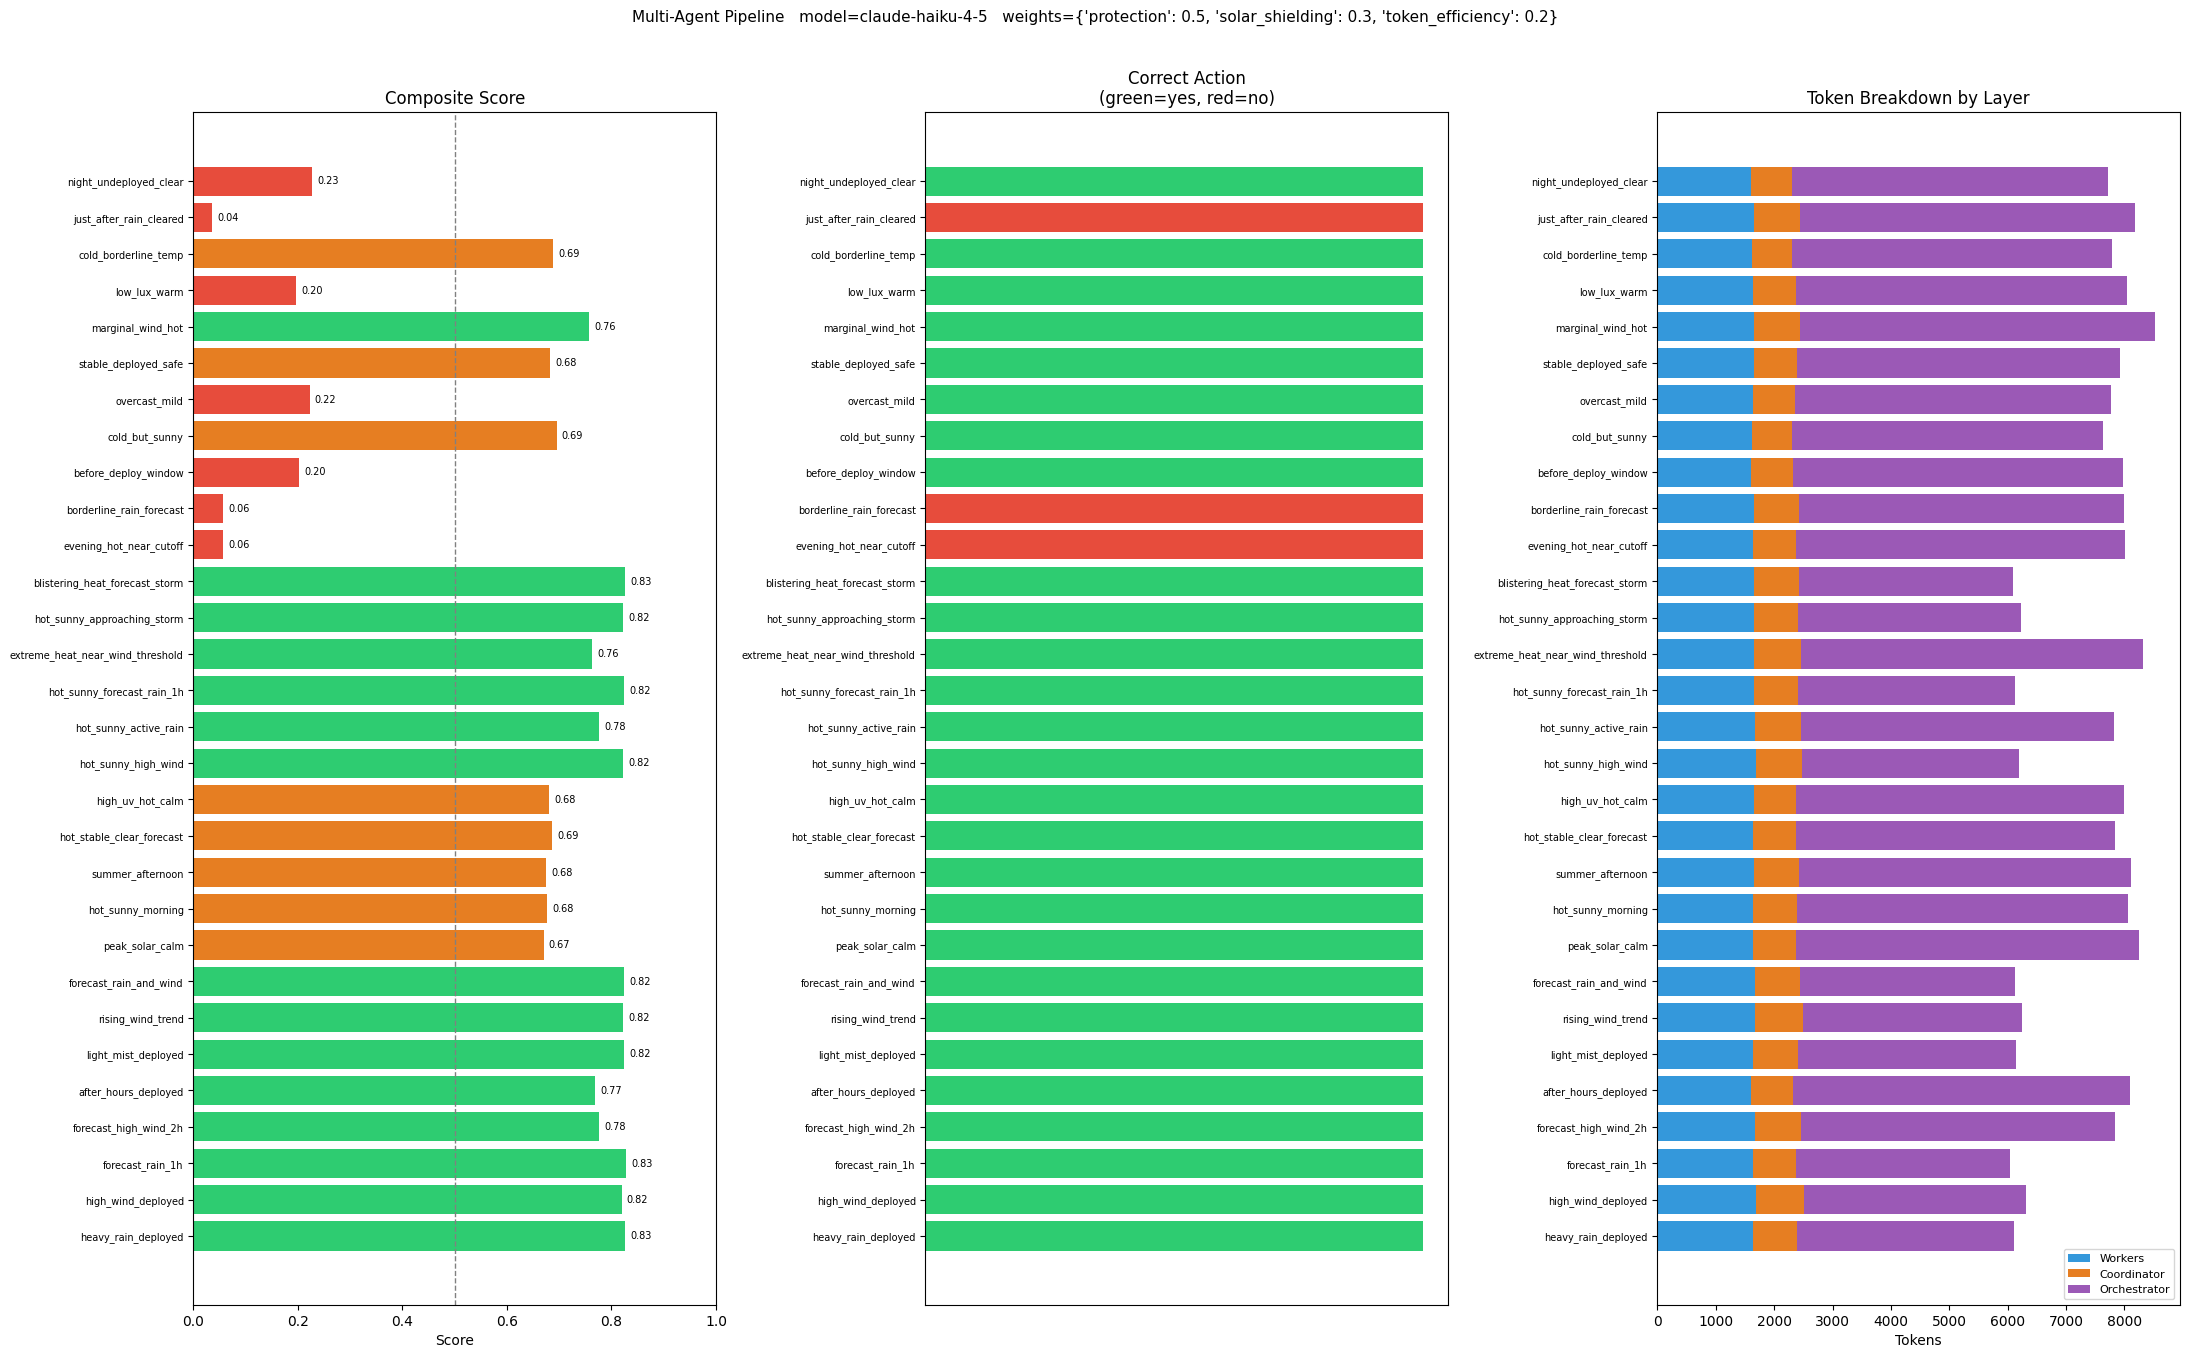

Saved: multi_agent_results.png


In [17]:
scenario_names = [r.scenario_name for r in all_results]
composites     = [row['composite'] for row in score_rows]
correct_flags  = [row['correct'] for row in score_rows]
y_pos = np.arange(len(scenario_names))

fig, axes = plt.subplots(1, 3, figsize=(22, max(7, len(scenario_names) * 0.38 + 2)))
fig.suptitle(f'Multi-Agent Pipeline   model={CLAUDE_MODEL}   weights={WEIGHTS}',
             fontsize=11, y=1.01)

# Chart 1: composite scores
ax1 = axes[0]
colors = ['#2ecc71' if v >= 0.7 else '#e67e22' if v >= 0.5 else '#e74c3c' for v in composites]
bars = ax1.barh(y_pos, composites, color=colors)
ax1.set_yticks(y_pos); ax1.set_yticklabels(scenario_names, fontsize=7)
ax1.set_xlim(0, 1); ax1.axvline(0.5, color='gray', linestyle='--', linewidth=1)
ax1.set_title('Composite Score'); ax1.set_xlabel('Score')
for bar, val in zip(bars, composites):
    ax1.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
             f'{val:.2f}', va='center', fontsize=7)

# Chart 2: correct/incorrect
ax2 = axes[1]
bar_colors = ['#2ecc71' if c else '#e74c3c' for c in correct_flags]
ax2.barh(y_pos, [1] * len(scenario_names), color=bar_colors)
ax2.set_yticks(y_pos); ax2.set_yticklabels(scenario_names, fontsize=7)
ax2.set_xticks([])
ax2.set_title('Correct Action\n(green=yes, red=no)')

# Group boundary lines on chart 2
for gb, label in [(8, 'A: Protect'), (13, 'B: Solar'), (21, 'C: Conflict'), (30, 'D: No-action')]:
    if gb < len(scenario_names):
        ax2.axhline(gb - 0.5, color='white', linewidth=1.5)

# Chart 3: token breakdown (stacked bar)
ax3 = axes[2]
wt = [r.worker_tokens for r in all_results]
ct = [r.coordinator_tokens for r in all_results]
ot = [r.orchestrator_tokens for r in all_results]
left2 = [a + b for a, b in zip(wt, ct)]
ax3.barh(y_pos, wt, label='Workers',      color='#3498db')
ax3.barh(y_pos, ct, left=wt,   label='Coordinator', color='#e67e22')
ax3.barh(y_pos, ot, left=left2, label='Orchestrator', color='#9b59b6')
ax3.set_yticks(y_pos); ax3.set_yticklabels(scenario_names, fontsize=7)
ax3.set_title('Token Breakdown by Layer'); ax3.set_xlabel('Tokens')
ax3.legend(fontsize=8)

plt.tight_layout()
plt.savefig('multi_agent_results.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: multi_agent_results.png')

## Section 11 — Drill-Down

Set `INSPECT` to any scenario name to view the full pipeline output for that run.

In [29]:
INSPECT = 'borderline_rain_forecast'   # <-- change this

r = next((x for x in all_results if x.scenario_name == INSPECT), None)
if r is None:
    print(f'Not found: {INSPECT}.  Available: {[x.scenario_name for x in all_results]}')
else:
    sc  = SCENARIOS_BY_NAME[r.scenario_name]
    ok  = r.action_taken == sc['expected_action']
    sep = '\u2500' * 64

    print(f'Scenario   : {r.scenario_name}')
    print(f'Expected   : {sc["expected_action"]}   Got: {r.action_taken}   {"CORRECT" if ok else "WRONG"}')
    print(f'Tokens     : workers={r.worker_tokens}  coord={r.coordinator_tokens}  orch={r.orchestrator_tokens}  total={r.total_tokens}')
    if r.deploy_seconds:    print(f'Deploy     : {r.deploy_seconds}s')
    if r.next_eval_seconds: print(f'Next eval  : {r.next_eval_seconds}s')
    if r.error:             print(f'ERROR      : {r.error}')

    for worker in [r.wind, r.rain, r.forecast, r.solar]:
        print(f'\n{sep}')
        print(f'WORKER: {worker.name.upper()}   in={worker.input_tokens}  out={worker.output_tokens}')
        print(sep)
        if worker.error:
            print(f'  ERROR: {worker.error}')
            print(f'  Raw  : {worker.raw_response[:300]}')
        else:
            print(json.dumps(worker.assessment, indent=2))

    print(f'\n{sep}')
    print('COORDINATOR BRIEF')
    print(sep)
    print(r.coordinator_brief)

    print(f'\n{sep}')
    print(f'ORCHESTRATOR   tools={r.orchestrator_tool_calls}')
    print(sep)
    print(r.orchestrator_report)

Scenario   : borderline_rain_forecast
Expected   : retract   Got: none   WRONG
Tokens     : workers=1646  coord=782  orch=5567  total=7995
Next eval  : 1800s

────────────────────────────────────────────────────────────────
WORKER: WIND   in=298  out=72
────────────────────────────────────────────────────────────────
{
  "risk": "none",
  "current_mph": 1.79,
  "trend": "stable",
  "reasoning": "Wind is stable at 1.79 mph, well below the 3.0 mph danger threshold with no rising trend."
}

────────────────────────────────────────────────────────────────
WORKER: RAIN   in=410  out=66
────────────────────────────────────────────────────────────────
{
  "risk": "none",
  "active_rain": false,
  "recent_rain_in_history": false,
  "reasoning": "No active precipitation detected and no rain recorded in recent history; awning is safe to deploy."
}

────────────────────────────────────────────────────────────────
WORKER: FORECAST   in=328  out=94
──────────────────────────────────────────────────